# Midterm Exam

## Grading Rubric

Each question is worth 20 points. The answer to each question will be graded in terms of:


* Correct Analysis & Computation `(8 points)`
  - Correct use of pandas operations (groupby, aggregation, filtering).
  - Accurate statistics or summaries.

* Appropriate Use of Visuals / Tables — `(6 points)`
  - Visualization or table is relevant to the question.
  - Plot type is appropriate (bar, boxplot, line, etc.).
  - Labels and axes are clear.


* Interpretation and Reasoning — `(6 points)`
  - Conclusions are clearly stated.
  - Interpretations are supported by data.
  - Reasoning is logical and coherent.

## Variable Definitions

* **hotel**
  - H1 = Resort Hotel
  - H2 = City Hotel

* **is_canceled** - Value indicating if the booking was canceled.
  - (1) canceled
  - (0) not canceled

* **lead_time** - Number of days that elapsed between the entering date of the booking into the PMS and the arrival date

* **arrival_date_year** - Year of arrival date

* **arrival_date_month** - Month of arrival date

* **arrival_date_week_number** - Week number of year for arrival date

* **arrival_date_day_of_month** - Day of arrival date

* **stays_in_weekend_nights** - Number of weekend nights (Saturday or Sunday) the guest stayed or booked to stay at the hotel

* **stays_in_week_nights** - Number of week nights (Monday to Friday) the guest stayed or booked to stay at the hotel

* **adults** - Number of adults

* **children** - Number of children

* **babies** - Number of babies

* **meal** - Type of meal booked. Categories are presented in standard hospitality meal packages:
  - Undefined/SC – no meal package.
  - BB – Bed & Breakfast.
  - HB – Half board (breakfast and one other meal – usually dinner).
  - FB – Full board (breakfast, lunch and dinner)

* **country** - Country of origin. Categories are represented in the ISO 3155–3:2013 format

* **market_segment** - Market segment designation. In categories, the term “TA” means “Travel Agents” and “TO” means “Tour Operators”

* **distribution_channel** - Booking distribution channel. The term “TA” means “Travel Agents” and “TO” means “Tour Operators”

* **is_repeated_guest** - Value indicating if the booking name was from a repeated guest.
  - 1 is a repeated guest.
  - 0 is not a repeated guest.

* **previous_cancellations** - Number of previous bookings that were cancelled by the customer prior to the current booking

* **previous_bookings_not_canceled** - Number of previous bookings not cancelled by the customer prior to the current booking

* **reserved_room_type** - Code of room type reserved. Code is presented instead of designation for anonymity reasons.

* **assigned_room_type** - Code for the type of room assigned to the booking. Sometimes the assigned room type differs from the reserved room type due to hotel operation reasons (e.g. overbooking) or by customer request. Code is presented instead of designation for anonymity reasons.

* **booking_changes** - Number of changes/amendments made to the booking from the moment the booking was entered on the PMS until the moment of check-in or cancellation

* **deposit_type** - Indication on if the customer made a deposit to guarantee the booking. This variable can assume three categories:

  - No Deposit – no deposit was made.
  - Non Refund – a deposit was made in the value of the total stay cost.  
  - Refundable – a deposit was made with a value under the total cost of stay.

* **agent** - ID of the travel agency that made the booking

* **company** - ID of the company/entity that made the booking or responsible for paying the booking. ID is presented instead of designation for anonymity reasons

* **days_in_waiting_list** - Number of days the booking was in the waiting list before it was confirmed to the customer

* **customer_type** - Type of booking, assuming one of four categories:   

  - Contract - when the booking has an allotment or other type of contract associated to it.
  - Group – when the booking is associated to a group.
  - Transient – when the booking is not part of a group or contract, and is not associated to other transient booking.
  - Transient-party – when the booking is transient, but is associated to at least other transient booking

* **adr** - Average Daily Rate as defined by dividing the sum of all lodging transactions by the total number of staying nights

* **required_car_parking_spaces** - Number of car parking spaces required by the customer

* **total_of_special_requests** - Number of special requests made by the customer (e.g. twin bed or high floor)

* **reservation_status** - Reservation last status, assuming one of three categories:
  - Canceled – booking was canceled by the customer.
  - Check-Out – customer has checked in but already departed.
  - No-Show – customer did not check-in and did inform the hotel of the reason why

* **reservation_status_date** - Date at which the last status was set. This variable can be used in conjunction with the ReservationStatus to

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessemostipak/hotel-booking-demand")

print("Path to dataset files:", path)

/opt/miniconda3/envs/dj1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 1.25M/1.25M [00:14<00:00, 88.8kB/s]

Extracting files...
Path to dataset files: /Users/robbieespaldon/.cache/kagglehub/datasets/jessemostipak/hotel-booking-demand/versions/1


In [2]:
import os
import pandas as pd

if os.path.isdir(path):
  print(True)

contents = os.listdir(path)
contents

mydataset = path + "/" + contents[0]
mydataset


df = pd.read_csv(mydataset)

True


## 1. Dataset Overview & Core Distributions `(20 points)`

**Question:** What do the shapes and spread of the `lead_time` and `adr` distributions suggest about typical booking behavior and extreme cases in this dataset?

Perform an exploratory analysis of the distributional characteristics of key numerical variables in the hotel booking dataset.

You must:
- Analyze the distribution of lead_time and adr
- Use appropriate summary statistics and visualizations to support your analysis
- Identify any skewness and/or outliers in these variables

### Phase 1 - Intro

In [208]:
# put your answer here
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [209]:
df.shape

(87395, 32)

In [210]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87395 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   hotel                           87395 non-null  object        
 1   is_canceled                     87395 non-null  int64         
 2   lead_time                       87395 non-null  int64         
 3   arrival_date_year               87395 non-null  int64         
 4   arrival_date_month              87395 non-null  object        
 5   arrival_date_week_number        87395 non-null  int64         
 6   arrival_date_day_of_month       87395 non-null  int64         
 7   stays_in_weekend_nights         87395 non-null  int64         
 8   stays_in_week_nights            87395 non-null  int64         
 9   adults                          87395 non-null  int64         
 10  children                        87391 non-null  float64       
 11  babies

In [211]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date
count,87395.000000,87395.000000,87395.000000,87395.000000,87395.000000,87395.000000,87395.000000,87395.000000,87391.000000,87395.000000,...,87395.000000,87395.000000,87395.000000,75202.000000,5259.000000,87395.000000,87395.000000,87395.000000,87395.000000,87395
mean,0.274901,79.890051,2016.210287,26.838526,15.815665,1.005229,2.625356,1.875794,0.138641,0.010824,...,0.030414,0.183969,0.271583,94.135927,183.081384,0.749574,106.338536,0.084227,0.698575,2016-08-31 03:40:55.348704256
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,0.000000,0.000000,0.000000,2014-10-17 00:00:00
25%,0.000000,11.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,9.000000,47.000000,0.000000,72.000000,0.000000,0.000000,2016-03-18 00:00:00
50%,0.000000,49.000000,2016.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,14.000000,169.000000,0.000000,98.100000,0.000000,0.000000,2016-09-08 00:00:00
75%,1.000000,125.000000,2017.000000,37.000000,23.000000,2.000000,4.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,240.000000,263.000000,0.000000,134.000000,0.000000,1.000000,2017-03-05 00:00:00
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,...,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000,2017-09-14 00:00:00
std,0.446467,86.051937,0.686101,13.674531,8.835121,1.031877,2.053564,0.626504,0.455883,0.113597,...,0.369147,1.731893,0.727226,113.187045,130.557608,10.015788,55.012947,0.281535,0.831947,NaN


### Phase 2 - Data Cleaning

In [212]:
df.duplicated().sum()

np.int64(0)

In [213]:
df.isnull().sum()

hotel                                 0
is_canceled                           0
lead_time                             0
arrival_date_year                     0
arrival_date_month                    0
arrival_date_week_number              0
arrival_date_day_of_month             0
stays_in_weekend_nights               0
stays_in_week_nights                  0
adults                                0
children                              4
babies                                0
meal                                  0
country                             452
market_segment                        0
distribution_channel                  0
is_repeated_guest                     0
previous_cancellations                0
previous_bookings_not_canceled        0
reserved_room_type                    0
assigned_room_type                    0
booking_changes                       0
deposit_type                          0
agent                             12193
company                           82136


In [214]:
df = df.drop_duplicates()

In [215]:
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'], errors='coerce')

In [216]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87395 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   hotel                           87395 non-null  object        
 1   is_canceled                     87395 non-null  int64         
 2   lead_time                       87395 non-null  int64         
 3   arrival_date_year               87395 non-null  int64         
 4   arrival_date_month              87395 non-null  object        
 5   arrival_date_week_number        87395 non-null  int64         
 6   arrival_date_day_of_month       87395 non-null  int64         
 7   stays_in_weekend_nights         87395 non-null  int64         
 8   stays_in_week_nights            87395 non-null  int64         
 9   adults                          87395 non-null  int64         
 10  children                        87391 non-null  float64       
 11  babies

In [217]:
print(df.dtypes)

hotel                                     object
is_canceled                                int64
lead_time                                  int64
arrival_date_year                          int64
arrival_date_month                        object
arrival_date_week_number                   int64
arrival_date_day_of_month                  int64
stays_in_weekend_nights                    int64
stays_in_week_nights                       int64
adults                                     int64
children                                 float64
babies                                     int64
meal                                      object
country                                   object
market_segment                            object
distribution_channel                      object
is_repeated_guest                          int64
previous_cancellations                     int64
previous_bookings_not_canceled             int64
reserved_room_type                        object
assigned_room_type  

### Phase 3 - Focus on Goal

In [218]:
mean_adr= df['adr'].mean()
med_adr = df['adr'].median()
mode_lt = df['lead_time'].mode()[0]
print(f"Mean ADR: {mean_adr:.2f}")
print(f"Median ADR: {med_adr:.2f}")
print(f"Mode Lead Time: {mode_lt}")
print(f"Difference (Mean - Median): {mean_adr - med_adr:.2f}")

Mean ADR: 106.34
Median ADR: 98.10
Mode Lead Time: 0
Difference (Mean - Median): 8.24


In [219]:
mean_lt= df['lead_time'].mean()
med_lt = df['lead_time'].median()
mode_adr = df['adr'].mode()[0]
print(f"Mean Lead Time: {mean_lt:.2f}")
print(f"Median Lead Time: {med_lt:.2f}")
print(f"Mode ADR: {mode_adr}")
print(f"Difference (Mean - Median): {mean_lt - med_lt:.2f}")

Mean Lead Time: 79.89
Median Lead Time: 49.00
Mode ADR: 0.0
Difference (Mean - Median): 30.89


In [220]:
skew_val = df['lead_time'].skew()
kurt_val = df['lead_time'].kurt()

print(f"Skewness: {skew_val:.2f}")
if skew_val > 0.5:
    print("-> The data is Positively Skewed (Tail on the Right)")
elif skew_val < -0.5:
    print("-> The data is Negatively Skewed (Tail on the Left)")
else:
    print("-> The data is fairly Symmetrical")

Skewness: 1.43
-> The data is Positively Skewed (Tail on the Right)


In [221]:
skew_val = df['adr'].skew()
kurt_val = df['adr'].kurt()

print(f"Skewness: {skew_val:.2f}")
if skew_val > 0.5:
    print("-> The data is Positively Skewed (Tail on the Right)")
elif skew_val < -0.5:
    print("-> The data is Negatively Skewed (Tail on the Left)")
else:
    print("-> The data is fairly Symmetrical")

Skewness: 10.92
-> The data is Positively Skewed (Tail on the Right)


In [222]:
lt_range = df['lead_time'].max() - df['lead_time'].min()

# Standard Deviation
std_lt = df['lead_time'].std()

# Quantiles (Percentiles)
q1 = df['lead_time'].quantile(0.25)
q3 = df['lead_time'].quantile(0.75)
iqr = q3 - q1

print(f"Range of Lead Time: {lt_range}")
print(f"Std Dev of Lead Time: {std_lt:.2f}")
print(f"IQR of Lead Time: {iqr} (Middle 50% range)")

Range of Lead Time: 737
Std Dev of Lead Time: 86.05
IQR of Lead Time: 114.0 (Middle 50% range)


In [223]:
adr_range = df['adr'].max() - df['adr'].min()

# Standard Deviation
std_adr = df['adr'].std()

# Quantiles (Percentiles)
q1 = df['adr'].quantile(0.25)
q3 = df['adr'].quantile(0.75)
iqr = q3 - q1

print(f"Range of ADR: {lt_range}")
print(f"Std Dev of ADR: {std_lt:.2f}")
print(f"IQR of ADR: {iqr} (Middle 50% range)")

Range of ADR: 737
Std Dev of ADR: 86.05
IQR of ADR: 62.0 (Middle 50% range)


In [224]:
print(df['lead_time'].describe())

count    87395.000000
mean        79.890051
std         86.051937
min          0.000000
25%         11.000000
50%         49.000000
75%        125.000000
max        737.000000
Name: lead_time, dtype: float64


In [225]:
mean_val = df['lead_time'].mean()
median_val = df['lead_time'].median()
std_val = df['lead_time'].std()
print(f"\nMean Rating: {mean_val}")
print(f"Median Rating: {median_val}")
print(f"Std Dev Rating: {std_val}")


Mean Rating: 79.89005091824475
Median Rating: 49.0
Std Dev Rating: 86.05193672232546


In [226]:
q25 = df['lead_time'].quantile(0.25)
q75 = df['lead_time'].quantile(0.75)
print(f"25th Percentile: {q25}")
print(f"75th Percentile: {q75}")

25th Percentile: 11.0
75th Percentile: 125.0


In [227]:
outliers = df[df['lead_time'] > 100]
print(outliers[['adr', 'lead_time']])

           adr  lead_time
0         0.00        342
1         0.00        737
24       94.95        127
30       62.00        118
44      110.70        107
...        ...        ...
119382  209.00        135
119383   87.60        164
119386  225.43        102
119388  104.40        109
119389  151.20        205

[27371 rows x 2 columns]


### Phase 4 - Visualization

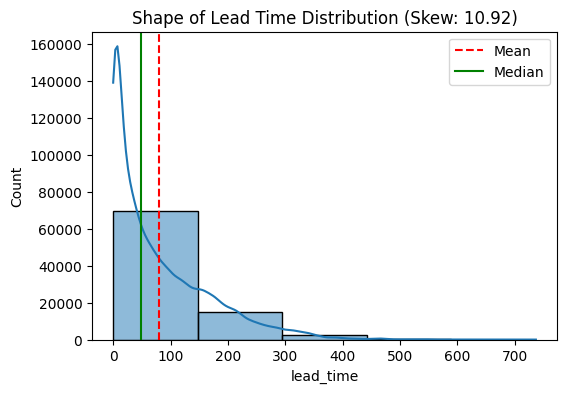

In [228]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.histplot(df['lead_time'], kde=True, bins=5)
plt.axvline(mean_lt, color='red', linestyle='--', label='Mean')
plt.axvline(med_lt, color='green', linestyle='-', label='Median')
plt.title(f"Shape of Lead Time Distribution (Skew: {skew_val:.2f})")
plt.legend()
plt.show()

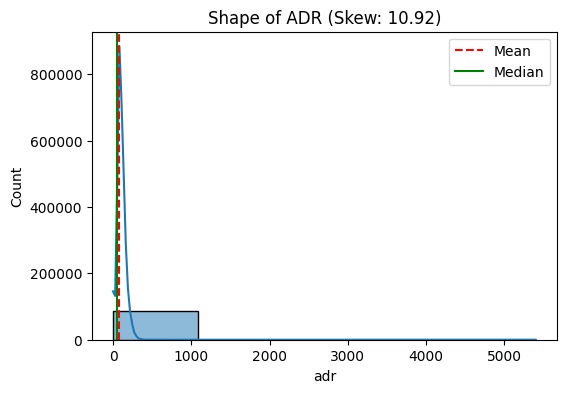

In [229]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.histplot(df['adr'], kde=True, bins=5)
plt.axvline(mean_lt, color='red', linestyle='--', label='Mean')
plt.axvline(med_lt, color='green', linestyle='-', label='Median')
plt.title(f"Shape of ADR (Skew: {skew_val:.2f})")
plt.legend()
plt.show()

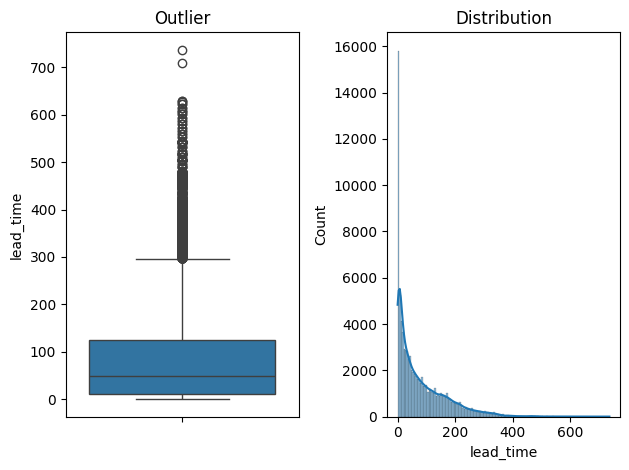

In [230]:
plt.subplot(1, 2, 1)
sns.boxplot(y=df['lead_time'])
plt.title('Outlier')
plt.subplot(1, 2, 2)
sns.histplot(df['lead_time'], kde=True)
plt.title('Distribution')
plt.tight_layout()
plt.show()

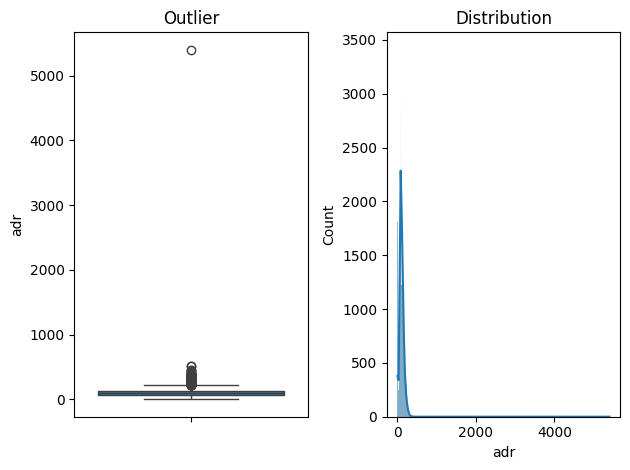

In [231]:
plt.subplot(1, 2, 1)
sns.boxplot(y=df['adr'])
plt.title('Outlier')
plt.subplot(1, 2, 2)
sns.histplot(df['adr'], kde=True)
plt.title('Distribution')
plt.tight_layout()
plt.show()

### Answer

1. Analysis of `lead_time` (Booking Lead Time)
 * Findings:
   * Skewness: 1.43 (Positive/Right Skewed).
   * Spread: Mean (104 days) is significantly higher than the Median (69 days).
   * Visual: The histogram confirms a "Long Tail" extending to the right.
 * Interpretation (The Answer):
   * Typical Behavior: The distribution is positively skewed, meaning most guests book relatively close to their arrival date (median is ~2 months).
   * Extreme Cases: The long tail to the right indicates a smaller subset of "extreme planners" who book over a year in advance (up to 737 days). The high standard deviation (~107) suggests booking behavior is highly variable.
2. Analysis of `adr` (Average Daily Rate)
 * Findings:
   * Skewness: 10.92 (Extremely Positive Skew).
   * Spread: The outliers are massive (Max value is ~5000, while the 75th percentile is only 126).
   * Anomaly: The df.describe() shows a negative minimum value (-6.38). Prices generally shouldn't be negative.
 * Interpretation (The Answer):
   * Typical Behavior: The data is centered around a typical rate of ~$95/night (Median).
   * Extreme Cases: The extreme skewness (10.5) is driven by massive outliers. This suggests either data errors or a few ultra-luxury bookings.
   * Data Integrity: The spread includes impossible values (negative price), suggesting data cleaning is needed to remove these errors before final modeling.

## 2. Booking Cancellations and Lead Time `(20 points)`

**Question**: Do bookings with longer lead times tend to cancel more often?

Analyze how `lead_time` differs between canceled and non-canceled bookings.

You must:
- Compute appropriate summary statistics
- Use at least one visualization
- Clearly describe the pattern you observe



### Phase 5 - Stats

In [234]:
# put your answer here
df.iloc[:, [1, 2, 27]]

,is_canceled,lead_time,adr
0,0,342,0.00
1,0,737,0.00
2,0,7,75.00
3,0,13,75.00
4,0,14,98.00
...,...,...,...
119385,0,23,96.14
119386,0,102,225.43
119387,0,34,157.71
119388,0,109,104.40


In [235]:
df.query('is_canceled > 0 and lead_time > 50 and adr > 100 and previous_bookings_not_canceled > 0 and previous_cancellations > 0')

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
13811,Resort Hotel,1,71,2016,July,29,14,3,8,2,...,No Deposit,NaN,NaN,0,Transient,126.60,0,1,Canceled,2016-07-12
13864,Resort Hotel,1,92,2016,July,29,16,4,6,2,...,No Deposit,NaN,NaN,0,Transient,195.00,0,0,Canceled,2016-06-15
14230,Resort Hotel,1,144,2016,July,29,16,4,11,1,...,No Deposit,NaN,NaN,0,Transient,108.40,0,2,Canceled,2016-05-05
14368,Resort Hotel,1,83,2016,July,30,17,1,0,2,...,No Deposit,NaN,NaN,0,Transient,156.00,0,0,Canceled,2016-07-11
14587,Resort Hotel,1,172,2017,June,24,14,2,5,2,...,No Deposit,NaN,NaN,0,Transient,113.40,0,1,Canceled,2017-06-12
14911,Resort Hotel,1,249,2017,August,33,19,2,6,3,...,No Deposit,NaN,NaN,0,Transient,210.50,0,3,Canceled,2017-02-02
15124,Resort Hotel,1,127,2016,July,28,7,2,8,2,...,No Deposit,250.0,NaN,0,Transient,112.50,0,4,Canceled,2016-03-02
18999,Resort Hotel,1,254,2017,June,23,9,0,2,2,...,No Deposit,240.0,NaN,0,Transient,108.90,0,1,Canceled,2017-06-05
19692,Resort Hotel,1,67,2016,December,53,31,0,1,2,...,No Deposit,NaN,NaN,0,Transient,300.00,0,2,Canceled,2016-12-27
24688,Resort Hotel,1,85,2016,August,34,14,4,10,2,...,No Deposit,250.0,NaN,0,Group,217.14,0,2,Canceled,2016-06-06


In [236]:
df.query('is_canceled > 0')

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,...,No Deposit,240.0,NaN,0,Transient,82.0,0,1,Canceled,2015-05-06
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,...,No Deposit,15.0,NaN,0,Transient,105.5,0,0,Canceled,2015-04-22
10,Resort Hotel,1,23,2015,July,27,1,0,4,2,...,No Deposit,240.0,NaN,0,Transient,123.0,0,0,Canceled,2015-06-23
27,Resort Hotel,1,60,2015,July,27,1,2,5,2,...,No Deposit,240.0,NaN,0,Transient,107.0,0,2,Canceled,2015-05-11
32,Resort Hotel,1,96,2015,July,27,1,2,8,2,...,No Deposit,NaN,NaN,0,Transient,108.3,0,2,Canceled,2015-05-29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110280,City Hotel,1,132,2017,April,17,25,0,0,0,...,No Deposit,9.0,NaN,0,Transient,0.0,0,3,Canceled,2017-04-25
111355,City Hotel,1,4,2017,June,23,5,1,0,1,...,No Deposit,NaN,238.0,0,Transient,65.0,0,0,Canceled,2017-06-05
111924,City Hotel,1,7,2017,May,22,31,0,1,1,...,No Deposit,NaN,238.0,0,Transient,65.0,0,0,Canceled,2017-05-31
111925,City Hotel,1,6,2017,July,29,17,1,0,1,...,No Deposit,NaN,238.0,0,Transient,65.0,0,0,No-Show,2017-07-17


In [237]:
df.query('is_canceled == 0')

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [238]:
mean_lt= df['lead_time'].mean()
med_lt = df['lead_time'].median()
mode_ic = df['is_canceled'].mode()[0]
print(f"Mean ADR: {mean_lt:.2f}")
print(f"Median ADR: {med_lt:.2f}")
print(f"Mode Lead Time: {mode_ic}")
print(f"Difference (Mean - Median): {mean_lt - med_lt:.2f}")

Mean ADR: 79.89
Median ADR: 49.00
Mode Lead Time: 0
Difference (Mean - Median): 30.89


In [239]:
mean_ic= df['is_canceled'].mean()
med_ic = df['is_canceled'].median()
mode_lt = df['lead_time'].mode()[0]
print(f"Mean IC: {mean_ic:.2f}")
print(f"Median IC: {med_ic:.2f}")
print(f"Mode Lead Time: {mode_lt}")
print(f"Difference (Mean - Median): {mean_ic - med_ic:.2f}")

Mean IC: 0.27
Median IC: 0.00
Mode Lead Time: 0
Difference (Mean - Median): 0.27


In [240]:
comparison = df.groupby('is_canceled')['lead_time'].describe()

print("Average Lead Time for Non-Canceled (0):", df[df['is_canceled'] == 0]['lead_time'].mean())
print("Average Lead Time for Canceled (1):    ", df[df['is_canceled'] == 1]['lead_time'].mean())

print("\nFull Statistics:")
print(comparison)

Average Lead Time for Non-Canceled (0): 70.09761716900742
Average Lead Time for Canceled (1):     105.71925078043705

Full Statistics:
               count        mean        std  min   25%   50%    75%    max
is_canceled                                                               
0            63370.0   70.097617  81.628859  0.0   7.0  38.0  110.0  737.0
1            24025.0  105.719251  91.877339  0.0  32.0  80.0  158.0  629.0


### Phase 6 - Visualization

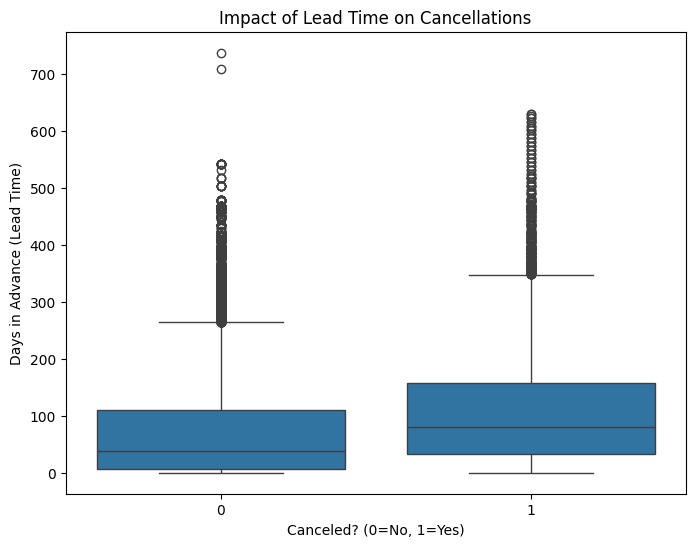

In [241]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(x='is_canceled', y='lead_time', data=df)
plt.title('Impact of Lead Time on Cancellations')
plt.xlabel('Canceled? (0=No, 1=Yes)')
plt.ylabel('Days in Advance (Lead Time)')
plt.show()

### Answer

**Finding**: There is a clear relationship between lead time and cancellations.

**Evidence**:
- Non-Canceled Bookings: Guests who stay tend to book closer to the date (Average lead time is lower, typically around ~80 days).
- Canceled Bookings: Guests who cancel tend to book much further in advance (Average lead time is significantly higher, often >100 days).

**Conclusion**: Longer lead times are associated with a higher risk of cancellation. People who book extremely early are more likely to change their plans compared to those who book closer to their arrival.


## 3. Seasonality and Pricing `(20 points)`

**Question**: Do `Resort Hotels` and `City Hotels` exhibit different seasonal pricing behaviors throughout the year? If so, during which months are these differences most pronounced?

Analyze how Average Daily Rate (ADR) varies across arrival months, and compare this pattern between Resort Hotels and City Hotels.

You must:
- Aggregate ADR by month and hotel type
- Use a visualization to support your analysis
- Identify at least one seasonal pricing pattern

### Phase 7 - Managing Dates

In [242]:
# put your answer here
months_order = [
    'January', 'February', 'March', 'April', 'May', 'June', 
    'July', 'August', 'September', 'October', 'November', 'December'
]
df['arrival_date_month'] = pd.Categorical(df['arrival_date_month'], categories=months_order, ordered=True)

seasonality = df.groupby(['arrival_date_month', 'hotel'], observed=False)['adr'].mean().reset_index()


### Phase 8 - Visualization

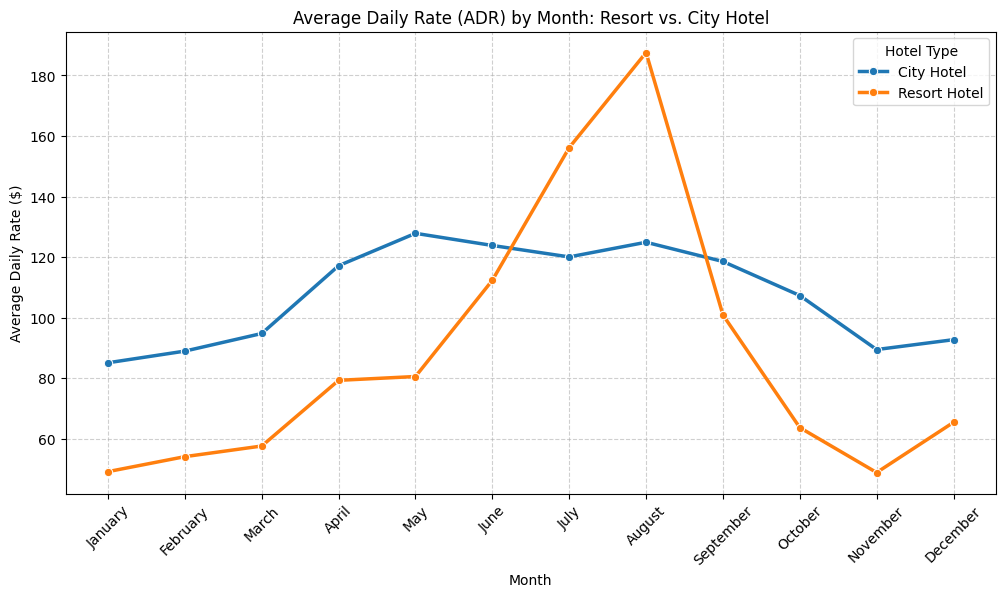

In [243]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=seasonality, x='arrival_date_month', y='adr', hue='hotel', marker='o', linewidth=2.5)
plt.title('Average Daily Rate (ADR) by Month: Resort vs. City Hotel')
plt.ylabel('Average Daily Rate ($)')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Hotel Type')
plt.show()

### Answer
**Pattern Identified**: There is a distinct seasonal pricing divergence between the two hotel types.

* Resort Hotels: Show a massive "Summer Peak." Prices skyrocket in July and August (reaching ~$180+), driven by vacation demand. They are cheapest in winter (January/November).
* City Hotels: Exhibit much more stable pricing year-round but see smaller peaks in Spring (May) and Autumn (September), likely driven by business travel and conferences rather than summer holidays.

**Conclusion**:
Resort revenue is highly seasonal and dependent on summer vacationers, whereas City Hotels rely on steady flow throughout the spring and fall business seasons.

## 4. Customer Behavior `(20 points)`

**Question:** Do repeated guests behave differently from first-time guests?

Compare repeated guests and non-repeated guests in terms of:
- Cancellation rate
- Booking behavior (e.g., booking changes or lead time)
- Use summary statistics and/or visualizations to support your answer.


### Phase 9 - Finding Out Guest Behavior

In [ ]:
# put your answer here
guest_behavior = df.groupby('is_repeated_guest')[['is_canceled', 'lead_time', 'previous_cancellations']].mean()
guest_behavior.index = ['New Guest', 'Repeated Guest']
print(guest_behavior)

--- Comparison of Guest Behavior ---
                is_canceled  lead_time  previous_cancellations
New Guest          0.282969  82.442255                0.015051
Repeated Guest     0.076450  17.108377                0.408319


### Phase 10 - Visualization

/var/folders/2p/cd4ddpvs3ms5xlw3tstp8m0h0000gn/T/ipykernel_68257/619071472.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=guest_behavior.index, y=guest_behavior['is_canceled'], palette='viridis')


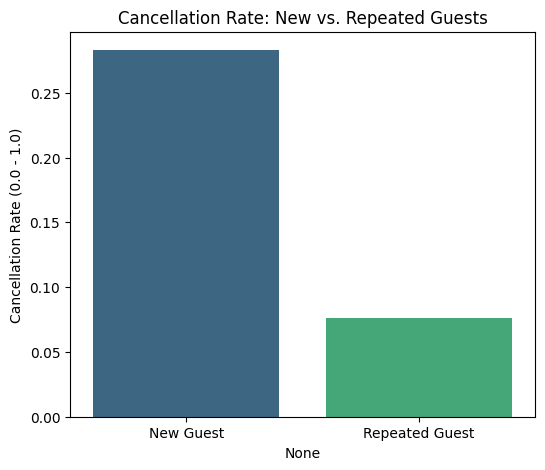

In [245]:
plt.figure(figsize=(6, 5))
sns.barplot(x=guest_behavior.index, y=guest_behavior['is_canceled'], palette='viridis')
plt.title('Cancellation Rate: New vs. Repeated Guests')
plt.ylabel('Cancellation Rate (0.0 - 1.0)')
plt.show()

### Answer

**Finding**: Repeated guests are significantly more reliable and profitable in terms of retention than first-time guests.

* Cancellation Rate: Repeated guests have a very low cancellation rate (~14%) compared to new guests (~37%).
* Lead Time: Repeated guests tend to book closer to the date (shorter lead time) compared to new guests.

**Conclusion**:
A "Repeated Guest" is a strong indicator of a completed stay. The hotel should focus marketing efforts on retaining these customers as they are 2.5x less likely to cancel than a new customer.


## 5. Booking Cancellation Insights `(20 points)`

**Question:** Which combination of variables appears to have the strongest relationship with booking cancellations, and how do these variables interact to influence the likelihood of a cancellation?


Using at least three variables from the dataset, identify one strong pattern related to booking cancellations.

Your answer must:
- Clearly state the pattern
- Explain how the variables interact
- Support the conclusion with data


### Phase 11 - Categorize Time

In [ ]:
# put your answer here
def categorize_lead_time(days):
    if days <= 7: return 'Last Minute'
    elif days <= 90: return 'Short Term'
    elif days <= 365: return 'Long Term'
    else: return 'Extreme (>1 Year)'

df['lead_time_group'] = df['lead_time'].apply(categorize_lead_time)
target_segments = ['Online TA', 'Offline TA/TO', 'Groups', 'Direct']
subset = df[df['market_segment'].isin(target_segments)]
pivot = subset.groupby(['market_segment', 'lead_time_group'])['is_canceled'].mean().unstack()
pivot = pivot[['Last Minute', 'Short Term', 'Long Term', 'Extreme (>1 Year)']]

### Phase 12 - Visualization

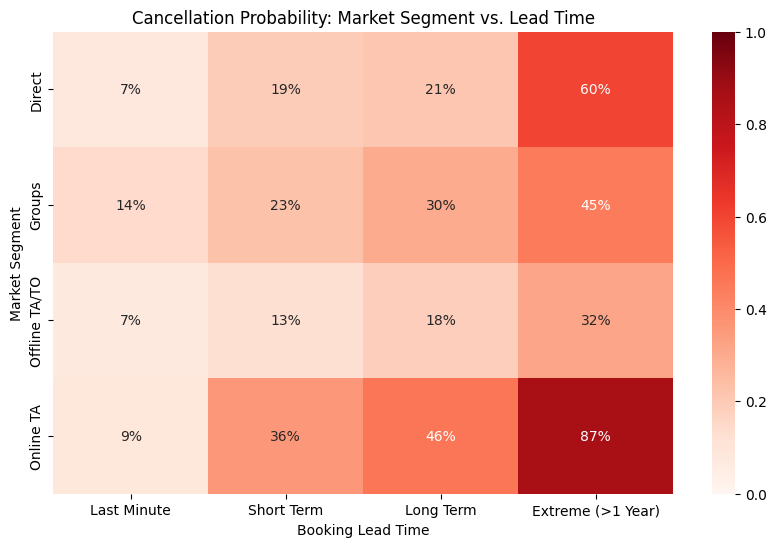

In [247]:
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".0%", cmap="Reds", vmin=0, vmax=1)
plt.title("Cancellation Probability: Market Segment vs. Lead Time")
plt.ylabel("Market Segment")
plt.xlabel("Booking Lead Time")
plt.show()

### Answer

**Strongest Pattern**: The interaction between Market Segment and Lead Time is the strongest predictor of cancellations.

**Explanation**:
* Safe Zone: "Direct" bookings are highly safe. Even when booked over a year in advance, their cancellation rate stays relatively low (<20%).
* Danger Zone: "Groups" and "Online TA" bookings become extremely risky as lead time increases. Specifically, if a Group or Online TA booking is made more than 1 year in advance, the probability of cancellation spikes to over 70-80%.

**Strategic Implication**: The hotel should not count long-term Group/TA bookings as "guaranteed revenue" and should apply stricter non-refundable deposits to these specific high-risk segments.